In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner
import os
from astropy.cosmology import FlatLambdaCDM, FlatwCDM
import astropy.units as u

os.makedirs('plots',  exist_ok=True)
os.makedirs('chains', exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

In [ ]:
## Load the MCMC chain from disk (if exists) --- UNCOMENT TO RUN RESULTS DIRECTLY FROM CHAINS ---
#import os
#if os.path.exists('chains/flat_lcdm_sne.npy'):
#    flat_lcdm_sne = np.load('chains/flat_lcdm_sne.npy')
#    flat_lcdm_cmb = np.load('chains/flat_lcdm_cmb.npy')
#    print('LCDM chains cargadas desde disco')

In [2]:
# Read the data
df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')
mask = (df['zHD'] > 0.01) & (df['IS_CALIBRATOR'] == 0)
df   = df[mask].reset_index(drop=True)

z_sn   = df['zHD'].values
mB     = df['mB'].values
x1     = df['x1'].values
c_     = df['c'].values
N_SNe  = len(z_sn)

with open('data/Pantheon+SH0ES_STATONLY.cov') as f:
    N_cov  = int(f.readline())
    C_full = np.array(f.read().split(), dtype=float).reshape(N_cov, N_cov)
orig_mask = (pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')
             .pipe(lambda d: (d['zHD']>0.01)&(d['IS_CALIBRATOR']==0)).values)
idx       = np.where(orig_mask)[0]
C_sn      = C_full[np.ix_(idx, idx)]
C_sn_inv  = np.linalg.inv(C_sn)
_, logdet_sn = np.linalg.slogdet(2*np.pi*C_sn)

M_fixed = -19.253   # Riess et al. 2022 / SH0ES (arXiv:2112.04510)

print(f'SNe Ia in fit: {N_SNe}   z range: {z_sn.min():.4f}-{z_sn.max():.4f}')

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_68150/538109132.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df   = pd.read_csv('data/Pantheon+SH0ES.dat', sep='\s+', comment='#')
/var/folders/sc/3sbv5zgs77zcpmwsqg_yfb500000gn/T/ipykernel_68150/538109132.py:15: Synt

SNe Ia in fit: 1580   z range: 0.0102-2.2614


In [3]:
# Table I of Chen, Huang & Wang (2019, arXiv:1808.05724), Planck 2018 TT,TE,EE+lowE
R_PLANCK, R_ERR       = 1.7502, 0.0046
OBH2_PLANCK, OBH2_ERR = 0.02236, 0.00015
RHO_R_OBH2            = -0.66

d_cmb   = np.array([R_PLANCK, OBH2_PLANCK])
cov_cmb = np.array([
    [R_ERR**2,                       RHO_R_OBH2*R_ERR*OBH2_ERR],
    [RHO_R_OBH2*R_ERR*OBH2_ERR,       OBH2_ERR**2]
])
cov_cmb_inv = np.linalg.inv(cov_cmb)
_, logdet_cmb = np.linalg.slogdet(2*np.pi*cov_cmb)

C_LIGHT = 299792.458   # km/s

def z_star_fit(Obh2, Omh2):
    """Recombination redshift fitting formula (Hu & Sugiyama 1996)."""
    g1 = 0.0783*(Obh2)**(-0.238) / (1 + 39.5*(Obh2)**0.763)
    g2 = 0.560 / (1 + 21.1*(Obh2)**1.81)
    return 1048*(1+0.00124*(Obh2)**(-0.738))*(1+g1*(Omh2)**g2)

def shift_parameter_R(H0, Om0, Obh2):
    """CMB shift parameter R(z*) for flat cosmologies. Uses astropy for D_A."""
    h     = H0/100
    Omh2  = Om0 * h**2
    zstar = z_star_fit(Obh2, Omh2)
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    DA    = cosmo.angular_diameter_distance(zstar).to(u.Mpc).value
    return (1+zstar) * DA * np.sqrt(Om0) * H0 / C_LIGHT

def log_likelihood_cmb(H0, Om0, Obh2):
    R    = shift_parameter_R(H0, Om0, Obh2)
    x    = np.array([R, Obh2])
    delta = x - d_cmb
    return -0.5 * (delta @ cov_cmb_inv @ delta + logdet_cmb)

In [14]:
# Faster luminosity_distance calculation for MCMC (compared to astropy) using numerical integration
from scipy.integrate import cumulative_trapezoid

Z_GRID = np.linspace(0, z_sn.max()*1.01, 2000)  # grilla fina, una sola vez

def luminosity_distance_fast(z_arr, H0, Om0, w=None):
    Ode0 = 1.0 - Om0
    if w is None:
        Ez = np.sqrt(Om0*(1+Z_GRID)**3 + Ode0)
    else:
        Ez = np.sqrt(Om0*(1+Z_GRID)**3 + Ode0*(1+Z_GRID)**(3*(1+w)))
    integrand = 1.0 / Ez
    DC_grid   = cumulative_trapezoid(integrand, Z_GRID, initial=0) * (C_LIGHT/H0)
    DC        = np.interp(z_arr, Z_GRID, DC_grid)
    return (1+z_arr) * DC

def mu_th_fast(model, H0, Om0, w=None):
    dL = luminosity_distance_fast(z_sn, H0, Om0, w)
    return 5*np.log10(dL) + 25

In [4]:
# Validarion of shift parameter calculation against Planck 2018 results
H0_fid, Om0_fid, Obh2_fid = 67.36, 0.3153, 0.02237
R_check     = shift_parameter_R(H0_fid, Om0_fid, Obh2_fid)
zstar_check = z_star_fit(Obh2_fid, Om0_fid*(H0_fid/100)**2)

print(f'z_star computed : {zstar_check:.2f}   (Planck reference: ~1089.9)')
print(f'R computed      : {R_check:.4f}   (Chen+2019 reference: {R_PLANCK})')
print(f'Relative error  : {100*abs(R_check-R_PLANCK)/R_PLANCK:.2f}%')

z_star computed : 1091.91   (Planck reference: ~1089.9)
R computed      : 1.7582   (Chen+2019 reference: 1.7502)
Relative error  : 0.46%


In [10]:
# Load priors and define likelihoods for SNe
BOUNDS = {
    'H0':    (50, 100),
    'Om0':   (0.05, 0.7),
    'w':     (-3.0, 0.0),
    'Obh2':  (0.018, 0.026),
    'alpha': (0.0, 1.0),
    'beta':  (1.0, 5.0),
}

def mu_th(model, H0, Om0, w=None):
    if model == 'LCDM':
        cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    else:
        cosmo = FlatwCDM(H0=H0, Om0=Om0, w0=w)
    return 5*np.log10(cosmo.luminosity_distance(z_sn).to(u.Mpc).value) + 25

def log_likelihood_sne(mu_theory, alpha, beta):
    mu_o  = mB + alpha*x1 - beta*c_ - M_fixed
    delta = mu_o - mu_theory
    return -0.5 * (delta @ C_sn_inv @ delta + logdet_sn)

def make_log_prob(model, use_cmb):
    """
    Builds a log-probability function for a given model ('LCDM' or 'wCDM')
    and whether to include the CMB distance prior.
    Parameter order: LCDM -> [H0, Om0, alpha, beta]      (+Obh2 if use_cmb)
                      wCDM -> [H0, Om0, w, alpha, beta]  (+Obh2 if use_cmb)
    """
    def log_prob(theta):
        if model == 'LCDM':
            if use_cmb:
                H0, Om0, alpha, beta, Obh2 = theta
            else:
                H0, Om0, alpha, beta = theta
            w = None
        else:
            if use_cmb:
                H0, Om0, w, alpha, beta, Obh2 = theta
            else:
                H0, Om0, w, alpha, beta = theta

        if not (BOUNDS['H0'][0]<H0<BOUNDS['H0'][1] and BOUNDS['Om0'][0]<Om0<BOUNDS['Om0'][1]
                and BOUNDS['alpha'][0]<alpha<BOUNDS['alpha'][1] and BOUNDS['beta'][0]<beta<BOUNDS['beta'][1]):
            return -np.inf
        if model == 'wCDM' and not (BOUNDS['w'][0]<w<BOUNDS['w'][1]):
            return -np.inf
        if use_cmb and not (BOUNDS['Obh2'][0]<Obh2<BOUNDS['Obh2'][1]):
            return -np.inf

        lp = log_likelihood_sne(mu_th_fast(model, H0, Om0, w), alpha, beta)
        if use_cmb:
            lp += log_likelihood_cmb(H0, Om0, Obh2)
        return lp
    return log_prob

In [6]:
# emcee sampler setup
def run_emcee(log_prob, theta0, scatter, nwalkers=64, nsteps=6000, warmup=1500):
    ndim = len(theta0)
    rng  = np.random.default_rng(42)
    pos  = np.empty((nwalkers, ndim))
    n = 0
    for _ in range(200_000):
        if n == nwalkers: break
        cand = theta0 + scatter * rng.standard_normal(ndim)
        if np.isfinite(log_prob(cand)):
            pos[n] = cand; n += 1
    if n < nwalkers:
        raise RuntimeError(f'Only {n}/{nwalkers} valid starting positions found')

    moves   = [(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)]
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, moves=moves)
    state   = sampler.run_mcmc(pos, warmup, progress=False)
    sampler.reset()
    sampler.run_mcmc(state, nsteps, progress=True)
    return sampler

def get_flat(sampler, burnin_factor=3):
    try:
        tau    = np.nan_to_num(sampler.get_autocorr_time(quiet=True), nan=100.0)
        burnin = int(burnin_factor*tau.max()); thin = max(1, int(tau.max()/2))
    except Exception:
        burnin, thin = 500, 10
    return sampler.get_chain(discard=burnin, thin=thin, flat=True), burnin, thin

def convergence_report(sampler, flat, label):
    chain = sampler.get_chain()
    af    = sampler.acceptance_fraction
    print(f'\n-- {label} --')
    print(f'  Acceptance fraction : mean={af.mean():.3f}')
    try:
        tau = np.nan_to_num(sampler.get_autocorr_time(quiet=True), nan=np.nan)
        print(f'  Autocorr time tau   : {np.round(tau,1)}')
        print(f'  Steps/tau (>50 ok)  : {np.round(chain.shape[0]/tau,1)}')
        print(f'  Effective samples   : {np.round(flat.shape[0]/tau).astype(int)}')
    except Exception:
        print('  Autocorr time       : could not compute')
    N, M_w, D = chain.shape
    W    = chain.var(axis=0, ddof=1).mean(axis=0)
    B    = N*chain.mean(axis=0).var(axis=0, ddof=1)
    Rhat = np.sqrt((N-1)/N + B/(N*W))
    print(f'  Gelman-Rubin R-hat  : {np.round(Rhat,4)}  (<1.01 converged)')

def print_results(flat, labels):
    print(f'  {"Param":>10}  {"16%":>9}  {"Median":>9}  {"84%":>9}')
    for i, lbl in enumerate(labels):
        p16,p50,p84 = np.percentile(flat[:,i], [16,50,84])
        print(f'  {lbl:>10}  {p16:>9.4f}  {p50:>9.4f}  {p84:>9.4f}')

In [7]:
# Runs: SNe Only vs SNe+CMB
lp_lcdm_sne = make_log_prob('LCDM', use_cmb=False)
theta0      = np.array([70.0, 0.3, 0.15, 3.1])
scatter     = np.array([2.0, 0.05, 0.01, 0.05])
labels_lcdm_sne = [r'$H_0$', r'$\Omega_m$', r'$\alpha$', r'$\beta$']

print('Running Flat LCDM -- SNe only...')
sampler_lcdm_sne = run_emcee(lp_lcdm_sne, theta0, scatter)
flat_lcdm_sne, _, _ = get_flat(sampler_lcdm_sne)

lp_lcdm_cmb = make_log_prob('LCDM', use_cmb=True)
theta0_c    = np.array([70.0, 0.3, 0.15, 3.1, 0.0224])
scatter_c   = np.array([1.0, 0.02, 0.01, 0.05, 0.0003])
labels_lcdm_cmb = labels_lcdm_sne + [r'$\Omega_b h^2$']

print('Running Flat LCDM -- SNe+CMB...')
sampler_lcdm_cmb = run_emcee(lp_lcdm_cmb, theta0_c, scatter_c)
flat_lcdm_cmb, _, _ = get_flat(sampler_lcdm_cmb)

Running Flat LCDM -- SNe only...


You must install the tqdm library to use progress indicators with emcee


Running Flat LCDM -- SNe+CMB...


You must install the tqdm library to use progress indicators with emcee


In [8]:
# Save results Flat LCDM
np.save('chains/flat_lcdm_sne.npy', flat_lcdm_sne)
np.save('chains/flat_lcdm_cmb.npy', flat_lcdm_cmb)
print('LCDM chains guardadas')

LCDM chains guardadas


In [ ]:
# Report results for LCDM
convergence_report(sampler_lcdm_sne, flat_lcdm_sne, 'Flat LCDM - SNe only')
print_results(flat_lcdm_sne, labels_lcdm_sne)

convergence_report(sampler_lcdm_cmb, flat_lcdm_cmb, 'Flat LCDM - SNe+CMB')
print_results(flat_lcdm_cmb, labels_lcdm_cmb)


-- Flat LCDM - SNe only --
  Acceptance fraction : mean=0.393
  Autocorr time tau   : [14.5 15.  14.6 14.6]
  Steps/tau (>50 ok)  : [413.4 400.7 412.1 409.9]
  Effective samples   : [3748 3633 3736 3717]
  Gelman-Rubin R-hat  : [1.0013 1.0012 1.0011 1.001 ]  (<1.01 converged)
       Param        16%     Median        84%
       $H_0$    71.9424    72.1229    72.3039
  $\Omega_m$     0.3521     0.3646     0.3773
    $\alpha$     0.1326     0.1360     0.1395
     $\beta$     2.4296     2.4745     2.5192

-- Flat LCDM - SNe+CMB --
  Acceptance fraction : mean=0.391
  Autocorr time tau   : [17.5 18.1 17.1 18.1 18.4]
  Steps/tau (>50 ok)  : [342.4 332.1 351.  331.6 325.7]
  Effective samples   : [2411 2338 2471 2335 2293]
  Gelman-Rubin R-hat  : [1.0019 1.0016 1.0012 1.0015 1.0018]  (<1.01 converged)
       Param        16%     Median        84%
       $H_0$    72.4554    72.6007    72.7429
  $\Omega_m$     0.3128     0.3194     0.3261
    $\alpha$     0.1348     0.1382     0.1416
     $\b

In [15]:
# Flat wCDM runs
lp_wcdm_sne = make_log_prob('wCDM', use_cmb=False)
theta0_w    = np.array([70.0, 0.3, -1.0, 0.15, 3.1])
scatter_w   = np.array([2.0, 0.05, 0.1, 0.01, 0.05])
labels_wcdm_sne = [r'$H_0$', r'$\Omega_m$', r'$w$', r'$\alpha$', r'$\beta$']

print('Running Flat wCDM -- SNe only...')
sampler_wcdm_sne = run_emcee(lp_wcdm_sne, theta0_w, scatter_w)
flat_wcdm_sne, _, _ = get_flat(sampler_wcdm_sne)

lp_wcdm_cmb = make_log_prob('wCDM', use_cmb=True)
theta0_wc   = np.array([70.0, 0.3, -1.0, 0.15, 3.1, 0.0224])
scatter_wc  = np.array([1.0, 0.02, 0.1, 0.01, 0.05, 0.0003])
labels_wcdm_cmb = labels_wcdm_sne + [r'$\Omega_b h^2$']

print('Running Flat wCDM -- SNe+CMB...')
sampler_wcdm_cmb = run_emcee(lp_wcdm_cmb, theta0_wc, scatter_wc)
flat_wcdm_cmb, _, _ = get_flat(sampler_wcdm_cmb)

Running Flat wCDM -- SNe only...


You must install the tqdm library to use progress indicators with emcee


Running Flat wCDM -- SNe+CMB...


You must install the tqdm library to use progress indicators with emcee


In [16]:
# Save results for Flat wCDM
np.save('chains/flat_wcdm_sne.npy', flat_wcdm_sne)
np.save('chains/flat_wcdm_cmb.npy', flat_wcdm_cmb)
print('wCDM chains guardadas')

wCDM chains guardadas


In [ ]:
# Report results for wCDM
convergence_report(sampler_wcdm_sne, flat_wcdm_sne, 'Flat wCDM - SNe only')
print_results(flat_wcdm_sne, labels_wcdm_sne)

convergence_report(sampler_wcdm_cmb, flat_wcdm_cmb, 'Flat wCDM - SNe+CMB')
print_results(flat_wcdm_cmb, labels_wcdm_cmb)


-- Flat wCDM - SNe only --
  Acceptance fraction : mean=0.342
  Autocorr time tau   : [20.3 25.2 26.  18.9 19.7]
  Steps/tau (>50 ok)  : [296.3 238.2 230.6 317.6 304.7]
  Effective samples   : [1438 1156 1119 1542 1479]
  Gelman-Rubin R-hat  : [1.0021 1.0019 1.002  1.0013 1.0014]  (<1.01 converged)
       Param        16%     Median        84%
       $H_0$    71.5652    71.7603    71.9667
  $\Omega_m$     0.1246     0.1914     0.2545
         $w$    -0.7674    -0.6799    -0.6035
    $\alpha$     0.1317     0.1351     0.1385
     $\beta$     2.4259     2.4697     2.5139

-- Flat wCDM - SNe+CMB --
  Acceptance fraction : mean=0.371
  Autocorr time tau   : [19.5 20.3 19.8 19.4 19.5 21.3]
  Steps/tau (>50 ok)  : [308.2 295.3 303.2 309.5 307.2 282.3]
  Effective samples   : [1950 1868 1918 1958 1943 1786]
  Gelman-Rubin R-hat  : [1.0016 1.0016 1.0015 1.0022 1.0018 1.0015]  (<1.01 converged)
       Param        16%     Median        84%
       $H_0$    71.7159    71.9045    72.0974
  $\Omeg

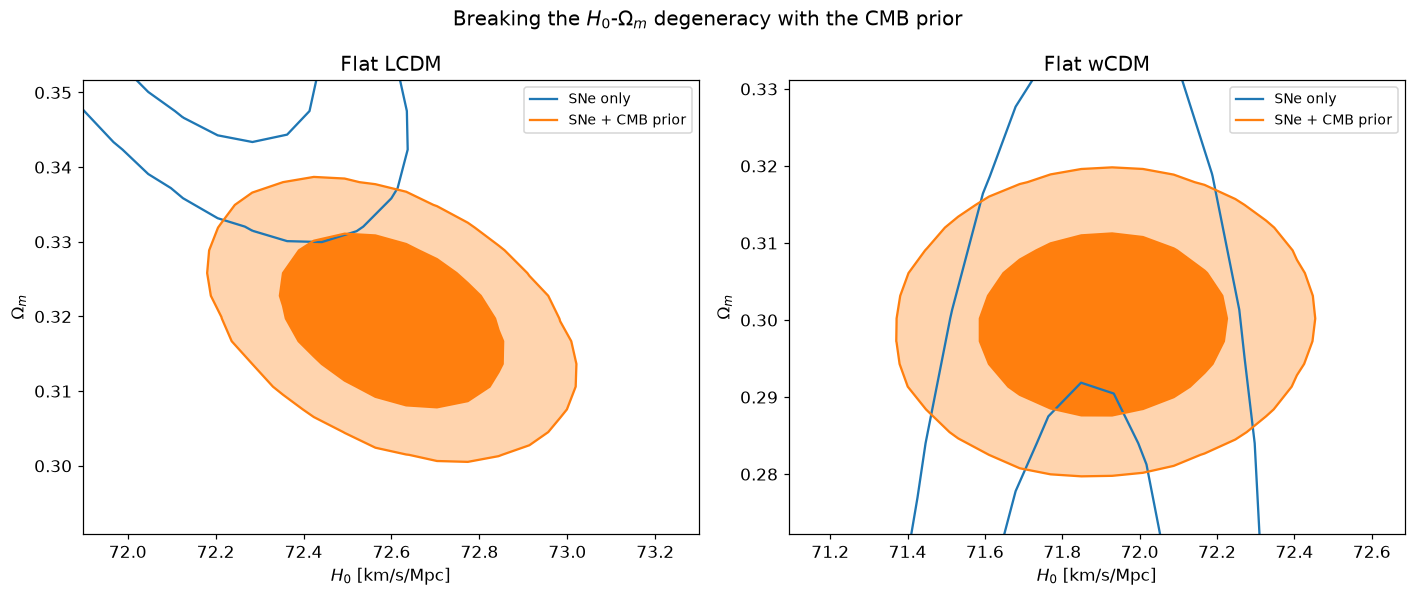

In [18]:
# Comparison of LCDM vs wCDM for H0 and Om0 (SNe only)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, flat_sne, flat_cmb, title in [
    (axes[0], flat_lcdm_sne, flat_lcdm_cmb, 'Flat LCDM'),
    (axes[1], flat_wcdm_sne, flat_wcdm_cmb, 'Flat wCDM'),
]:
    corner.hist2d(flat_sne[:,0], flat_sne[:,1], levels=[0.68,0.95],
                  color='C0', plot_datapoints=False, plot_density=False,
                  fill_contours=False, smooth=1.2, ax=ax)
    corner.hist2d(flat_cmb[:,0], flat_cmb[:,1], levels=[0.68,0.95],
                  color='C1', plot_datapoints=False, plot_density=True,
                  fill_contours=True, smooth=1.2, ax=ax)
    ax.plot([], [], color='C0', label='SNe only')
    ax.plot([], [], color='C1', label='SNe + CMB prior')
    ax.set_xlabel(r'$H_0$ [km/s/Mpc]'); ax.set_ylabel(r'$\Omega_m$')
    ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle(r'Breaking the $H_0$-$\Omega_m$ degeneracy with the CMB prior', fontsize=13)
plt.tight_layout()
plt.savefig('plots/degeneracy_breaking.png', dpi=130, bbox_inches='tight')
plt.show()

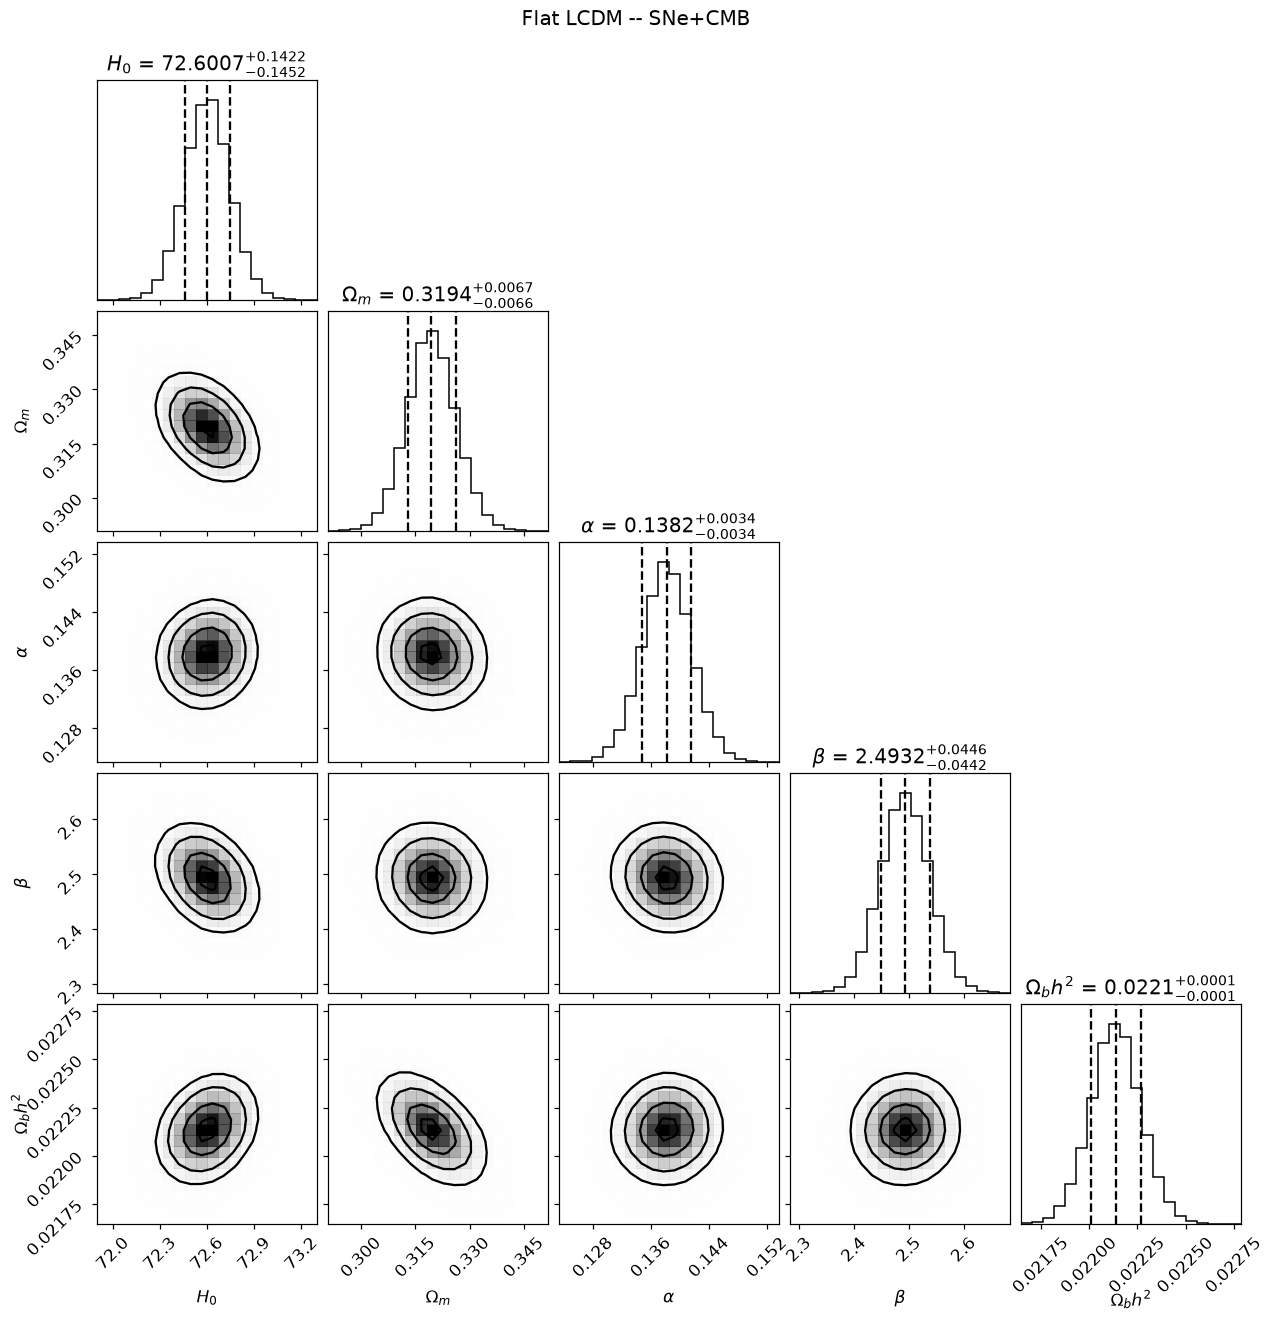

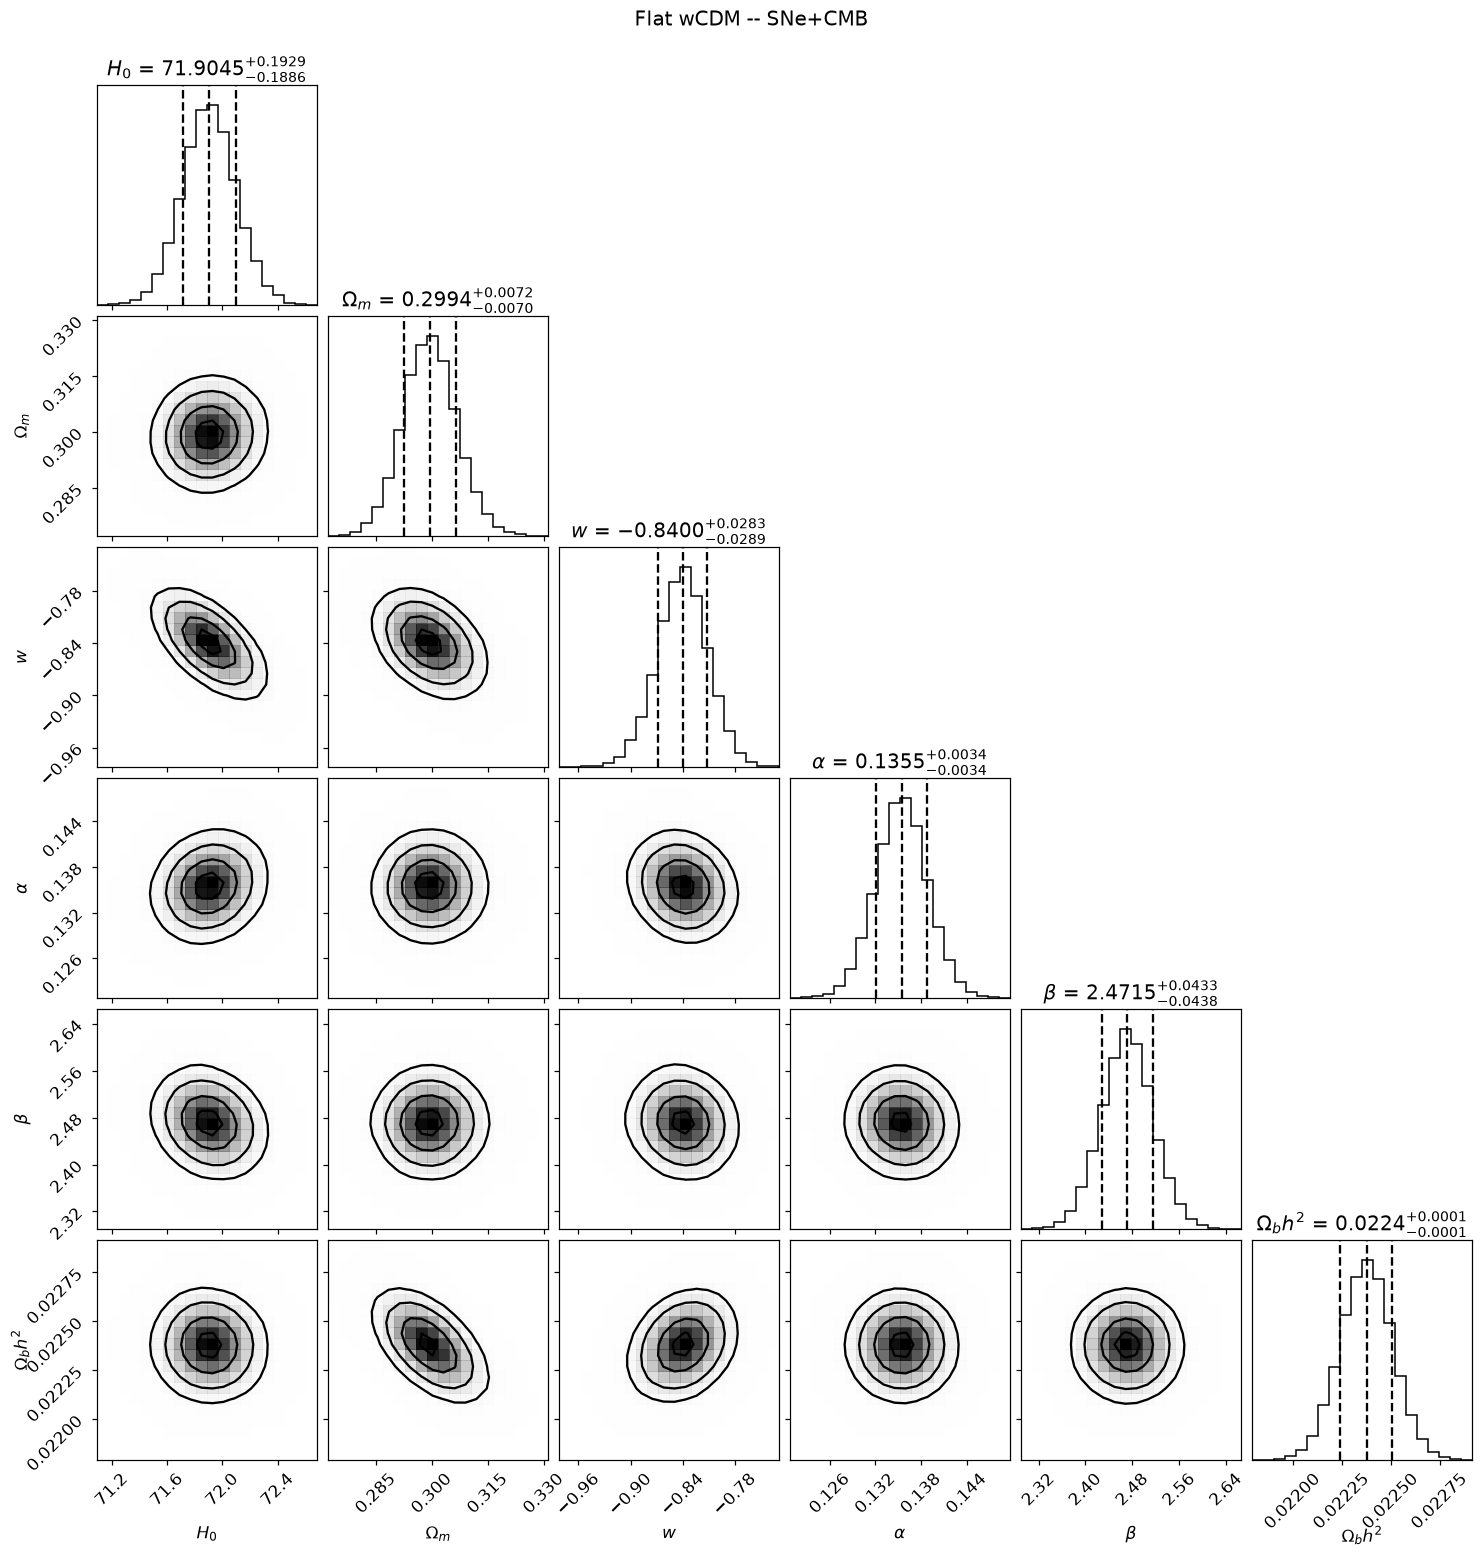

In [19]:
# Full Corner Plot for wCDM with SNe+CMB
for flat, labels, title, fname in [
    (flat_lcdm_cmb, labels_lcdm_cmb, 'Flat LCDM -- SNe+CMB', 'corner_lcdm_cmb.png'),
    (flat_wcdm_cmb, labels_wcdm_cmb, 'Flat wCDM -- SNe+CMB', 'corner_wcdm_cmb.png'),
]:
    fig = corner.corner(flat, labels=labels, quantiles=[0.16,0.5,0.84],
                        show_titles=True, title_fmt='.4f',
                        plot_datapoints=False, smooth=1.0)
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.savefig(f'plots/{fname}', dpi=110, bbox_inches='tight')
    plt.show()

In [21]:
# AIC and BIC comparison
def loglike_from_theta(model, use_cmb, theta):
    if model == 'LCDM':
        if use_cmb: H0, Om0, alpha, beta, Obh2 = theta
        else:       H0, Om0, alpha, beta       = theta
        w = None
    else:
        if use_cmb: H0, Om0, w, alpha, beta, Obh2 = theta
        else:       H0, Om0, w, alpha, beta       = theta
    ll = log_likelihood_sne(mu_th_fast(model, H0, Om0, w), alpha, beta)
    if use_cmb:
        ll += log_likelihood_cmb(H0, Om0, Obh2)
    return ll

configs = {
    'LCDM SNe-only' : ('LCDM', False, flat_lcdm_sne, 4),
    'LCDM SNe+CMB'  : ('LCDM', True,  flat_lcdm_cmb, 5),
    'wCDM SNe-only' : ('wCDM', False, flat_wcdm_sne, 5),
    'wCDM SNe+CMB'  : ('wCDM', True,  flat_wcdm_cmb, 6),
}

N_data = {'SNe-only': N_SNe, 'SNe+CMB': N_SNe + 2}

print(f'{"Config":18s}  {"k":>3}  {"lnL_max":>10}  {"AIC":>9}  {"BIC":>9}')
print('-'*55)
results_table = {}
for name, (model, use_cmb, flat, k) in configs.items():
    lls  = np.array([loglike_from_theta(model, use_cmb, s) for s in flat[::10]])
    lmax = lls.max()
    N    = N_data['SNe+CMB'] if use_cmb else N_data['SNe-only']
    aic  = 2*k - 2*lmax
    bic  = k*np.log(N) - 2*lmax
    results_table[name] = (lmax, aic, bic, k)
    print(f'{name:18s}  {k:>3}  {lmax:>10.2f}  {aic:>9.2f}  {bic:>9.2f}')

print('\nDelta(AIC), Delta(BIC) of wCDM relative to LCDM, per data configuration:')
for cfg in ['SNe-only', 'SNe+CMB']:
    d_aic = results_table[f'wCDM {cfg}'][1] - results_table[f'LCDM {cfg}'][1]
    d_bic = results_table[f'wCDM {cfg}'][2] - results_table[f'LCDM {cfg}'][2]
    print(f'  {cfg:10s}: Delta AIC = {d_aic:+.2f}   Delta BIC = {d_bic:+.2f}')

Config                k     lnL_max        AIC        BIC
-------------------------------------------------------
LCDM SNe-only         4      758.42   -1508.85   -1487.38
LCDM SNe+CMB          5      762.94   -1515.87   -1489.04
wCDM SNe-only         5      762.47   -1514.93   -1488.11
wCDM SNe+CMB          6      773.74   -1535.49   -1503.29

Delta(AIC), Delta(BIC) of wCDM relative to LCDM, per data configuration:
  SNe-only  : Delta AIC = -6.09   Delta BIC = -0.72
  SNe+CMB   : Delta AIC = -19.61   Delta BIC = -14.25


SNe only  : w = -0.680 +0.076 -0.087
SNe+CMB   : w = -0.840 +0.028 -0.029


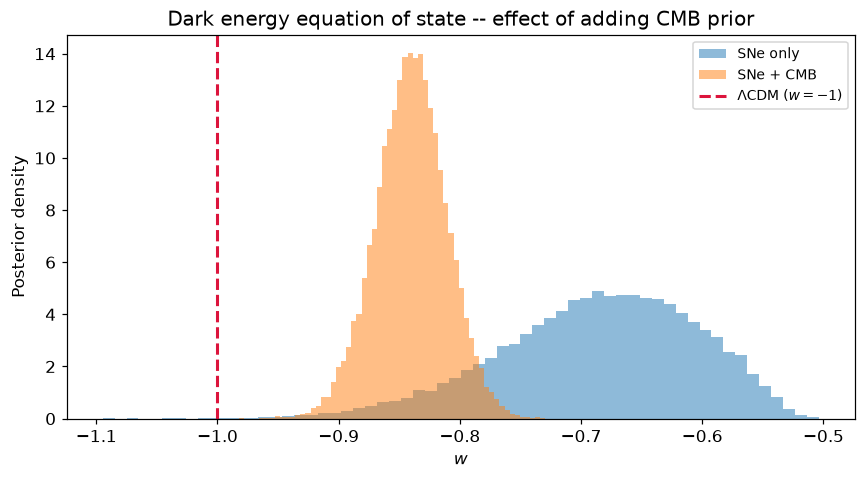

In [22]:
# Equation of state w constraint: With and without CMB prior
fig, ax = plt.subplots(figsize=(8, 4.5))
w_sne = flat_wcdm_sne[:, 2]
w_cmb = flat_wcdm_cmb[:, 2]

ax.hist(w_sne, bins=60, density=True, color='C0', alpha=0.5, label='SNe only')
ax.hist(w_cmb, bins=60, density=True, color='C1', alpha=0.5, label='SNe + CMB')
ax.axvline(-1, color='crimson', lw=2, ls='--', label=r'$\Lambda$CDM ($w=-1$)')

for w_arr, lbl in [(w_sne,'SNe only'), (w_cmb,'SNe+CMB')]:
    p16,p50,p84 = np.percentile(w_arr, [16,50,84])
    print(f'{lbl:10s}: w = {p50:.3f} +{p84-p50:.3f} -{p50-p16:.3f}')

ax.set_xlabel(r'$w$'); ax.set_ylabel('Posterior density')
ax.set_title('Dark energy equation of state -- effect of adding CMB prior')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/w_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [23]:
# Summary table of results
print(f'{"Config":18s}  {"H0":>16}  {"Omega_m":>14}  {"w":>16}')
print('-'*70)
for name, flat, has_w in [
    ('LCDM SNe-only', flat_lcdm_sne, False),
    ('LCDM SNe+CMB',  flat_lcdm_cmb, False),
    ('wCDM SNe-only', flat_wcdm_sne, True),
    ('wCDM SNe+CMB',  flat_wcdm_cmb, True),
]:
    p16,p50,p84 = np.percentile(flat[:,0], [16,50,84])
    H0_str = f'{p50:.2f} +{p84-p50:.2f}/-{p50-p16:.2f}'
    p16,p50,p84 = np.percentile(flat[:,1], [16,50,84])
    Om_str = f'{p50:.3f} +{p84-p50:.3f}/-{p50-p16:.3f}'
    if has_w:
        p16,p50,p84 = np.percentile(flat[:,2], [16,50,84])
        w_str = f'{p50:.3f} +{p84-p50:.3f}/-{p50-p16:.3f}'
    else:
        w_str = '-1 (fixed)'
    print(f'{name:18s}  {H0_str:>16}  {Om_str:>14}  {w_str:>16}')

Config                            H0         Omega_m                 w
----------------------------------------------------------------------
LCDM SNe-only       72.12 +0.18/-0.18  0.365 +0.013/-0.013        -1 (fixed)
LCDM SNe+CMB        72.60 +0.14/-0.15  0.319 +0.007/-0.007        -1 (fixed)
wCDM SNe-only       71.76 +0.21/-0.20  0.191 +0.063/-0.067  -0.680 +0.076/-0.087
wCDM SNe+CMB        71.90 +0.19/-0.19  0.299 +0.007/-0.007  -0.840 +0.028/-0.029
